# 1 · USGS Hydrography & WaterData

This is the **first notebook** in the Thornforest hydrology series. It builds the
*spatial foundation* that every later notebook relies on, and then begins discovering
what monitoring data is available.

Our project focuses on **three HUC-8 subbasins** in South Texas.
- South Laguna Madre (12110208)
- Los Olmos (13090001)
- Lower Rio Grande (13090002)

**In this first part we will:**

1. Look up the **boundaries** of our three watersheds of interest,
2. Draw them on an **interactive map**,
3. **Discover the monitoring stations** within them, and
4. See **which data types** (daily, continuous, field measurements, samples) each offers.

> **New to Python notebooks?** A Jupyter notebook is a list of *cells*. A cell holds
> either explanatory text (like this one) or Python code. Run a code cell by selecting
> it and pressing **Shift + Enter**. Run the cells **in order from top to bottom** — each
> one builds on the ones above it.

## Step 1 — Load the Python tools we need

Each `import` line loads a software library (a toolbox of ready-made functions):

- **`pygeohydro`** — part of the [HyRiver](https://docs.hyriver.io/) suite; its `WBD`
  tool downloads boundaries from the USGS **W**atershed **B**oundary **D**ataset.
- **`dataretrieval`** — the USGS package for the new **Water Data** API; its `waterdata`
  module lists and downloads monitoring-station data.
- **`geopandas`** — works with *geographic* tables, where each row has a shape (a
  "geometry"); we use it to keep only the stations that fall inside our watersheds.
- **`geoviews`** — makes interactive maps you can pan, zoom, and hover over.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
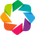

In [1]:
from pygeohydro import WBD
from dataretrieval import waterdata

import geopandas as gpd
import geoviews as gv
import geoviews.tile_sources as gvts

# Turn on GeoViews' interactive (Bokeh) plotting. Run this once per session.
gv.extension("bokeh")

## Step 1b — API key, request caching, and saved outputs

Three setup pieces keep the downloads fast and reproducible:

- **Optional API key.** `load_dotenv()` reads an `API_USGS_PAT` key from a local `.env` file
  if you created one (see the README); it raises the USGS rate limits. Everything still runs
  without a key, just under stricter anonymous limits.
- **A persistent request cache.** Web requests are cached on disk in a **git-ignored
  `cache/`** folder (shared by HyRiver and [`async-retriever`](https://docs.hyriver.io/readme/async-retriever.html))
  and reused for a week, so re-running doesn't re-download. Delete `cache/` to force fresh
  requests. `async-retriever` also lets us fire the many per-station requests in Step 6
  **concurrently** rather than one at a time.
- **Saved outputs.** Each section also writes its result to **`data/`** in two formats: a
  **GeoParquet** file (compact, typed — what the other notebooks read) *and* a **CSV** copy
  (human-readable, with geometry as WKT) for transparency. These committed files are the
  shareable products of this notebook.

Reusable utilities (`find_repo_root`, `save_outputs`, `show`) live in **`notebooks/_helpers.py`**
so they can be shared across notebooks; the rest of this cell is the project-specific config.

In [2]:
import os
from io import StringIO
from urllib.parse import quote

import pandas as pd
import async_retriever as ar
from dotenv import load_dotenv

from _helpers import find_repo_root, save_outputs, show

REPO_ROOT = find_repo_root()

# 1. Optional USGS API key — loaded from .env if present (raises rate limits); runs fine without.
load_dotenv(REPO_ROOT / ".env")
API_KEY = os.getenv("API_USGS_PAT")
API_HEADERS = {"X-Api-Key": API_KEY} if API_KEY else {}
print("USGS API key loaded." if API_KEY else "No API key — using anonymous (lower) rate limits.")

# 2. Persistent HTTP request cache (git-ignored), shared by HyRiver + async-retriever; 1-week expiry.
CACHE_FILE = str(REPO_ROOT / "cache" / "aiohttp_cache.sqlite")
CACHE_EXPIRE_SECONDS = 7 * 24 * 3600
os.environ.setdefault("HYRIVER_CACHE_NAME", CACHE_FILE)
os.environ.setdefault("HYRIVER_CACHE_EXPIRE", str(CACHE_EXPIRE_SECONDS))

# 3. Curated, shareable outputs (committed to the repo) — later notebooks read these.
DATA_DIR = REPO_ROOT / "data"

USGS API key loaded.


## Step 2 — Name our three watersheds

We store the three HUC-8 codes and their names in a **dictionary** — a lookup table that
maps each code (the "key") to a friendly name (the "value"). We also pick a distinct
color for each, so they are easy to tell apart on the map.

In [3]:
# HUC-8 code  ->  watershed name
HUC8_WATERSHEDS = {
    "12110208": "South Laguna Madre",
    "13090001": "Los Olmos",
    "13090002": "Lower Rio Grande",
}

# HUC-8 code  ->  map color (colorblind-friendly)
HUC8_COLORS = {
    "12110208": "#1b9e77",  # teal-green
    "13090001": "#d95f02",  # orange
    "13090002": "#7570b3",  # purple
}

## Step 3 — Download the watershed boundaries

`WBD("huc8")` connects to the USGS Watershed Boundary Dataset service for HUC-8 areas.
Its `.byids()` method fetches specific watersheds **by their ID codes** — here, the three
codes from our dictionary (`list(HUC8_WATERSHEDS)` gives just the codes).

The request is cached on disk (see Step 1b), so re-runs are fast; the result is also saved
to `data/spatial/` as a shareable output.

In [4]:
watersheds_gdf = WBD("huc8").byids("huc8", list(HUC8_WATERSHEDS))
save_outputs(watersheds_gdf, DATA_DIR / "spatial" / "huc8_watersheds.parquet")
print(f"{len(watersheds_gdf)} watershed boundaries.")

saved 3 rows → data/spatial/huc8_watersheds.parquet (+ .csv)
3 watershed boundaries.


### What did we get back?

The result is a **GeoDataFrame**: a spreadsheet-like table where every row is one
watershed, with a special `geometry` column holding its boundary shape. Let's peek at a
few useful columns — the code, the name, and the area in square kilometers.

The `.crs` ("coordinate reference system") tells us the coordinates are plain
**longitude/latitude** (EPSG:4326), the most common geographic system.

In [5]:
print("Coordinate system:", watersheds_gdf.crs)

# Show just the human-readable columns (not the long geometry shapes).
show(watersheds_gdf[["huc8", "name", "areasqkm", "states"]])

Coordinate system: EPSG:4326


,huc8,name,areasqkm,states
0,12110208,South Laguna Madre,7730.32,TX
1,13090002,Lower Rio Grande,5501.93,"MX,TX"
2,13090001,Los Olmos,8145.84,"MX,TX"


## Step 4 — Map the watersheds

Now we draw the boundaries on a real-world basemap. We build the map in layers:

1. **`gvts.EsriWorldTopo`** — Esri's World Topographic Map (terrain shading, roads, and
   place names) for geographic context.
2. One **`gv.Polygons`** layer per watershed, each in its own color, so we get a legend.

The `*` symbol **stacks layers** on top of each other into a single combined map.

> **How to explore the map:** *hover* over a watershed to see its name and area; use the
> toolbar on the right to **zoom**, **pan**, and **reset**; click legend entries to focus.

In [6]:
# Build one colored layer per watershed (a loop avoids repeating the same code 3 times).
watershed_layers = []
for code, name in HUC8_WATERSHEDS.items():
    one_watershed = watersheds_gdf[watersheds_gdf["huc8"] == code]
    layer = gv.Polygons(
        one_watershed,
        vdims=["name", "huc8", "areasqkm"],  # columns shown in the hover tooltip
        label=name,                           # text shown in the legend
    ).opts(
        color=HUC8_COLORS[code],
        line_color=HUC8_COLORS[code],
        alpha=0.45,        # fill transparency, so the basemap shows through
        line_width=2,
        tools=["hover"],
    )
    watershed_layers.append(layer)

# Stack the basemap and all watershed layers into one map.
watersheds_map = gvts.EsriWorldTopo
for layer in watershed_layers:
    watersheds_map = watersheds_map * layer

# Final styling. We set the map *width* and lock `data_aspect=1` so that the height is
# computed automatically to match the watersheds' true geographic proportions. This keeps
# map pixels square — otherwise the basemap tiles get stretched and look blurry.
watersheds_map = watersheds_map.opts(
    frame_width=850,
    data_aspect=1,
    title="Three HUC-8 Watersheds — Thornforest Study Area (South Texas)",
    legend_position="top_left",
    active_tools=["wheel_zoom"],
)

watersheds_map

:Overlay
   .WMTS.I                      :WMTS   [Longitude,Latitude]
   .Polygons.South_Laguna_Madre :Polygons   [Longitude,Latitude]   (name,huc8,areasqkm)
   .Polygons.Los_Olmos          :Polygons   [Longitude,Latitude]   (name,huc8,areasqkm)
   .Polygons.Lower_Rio_Grande   :Polygons   [Longitude,Latitude]   (name,huc8,areasqkm)

## Step 5 — Discover monitoring stations

With the study area defined, we can ask **what monitoring data exists** there. We use the
new USGS **Water Data** API (the modern replacement for the legacy NWIS) through the
`dataretrieval.waterdata` module. Its `get_monitoring_locations()` function lists stations
— stream gauges, wells, water-quality sites, and more.

The API filters by a rectangular **bounding box**, so we do this in two steps:

1. ask for every station in the box around our watersheds, then
2. keep only those that fall **inside** the actual (irregular) watershed boundaries, using
   a *spatial join* (`geopandas.sjoin`).

(No API key is required; one only raises rate limits — see the README.)

In [7]:
# total_bounds gives [min_lon, min_lat, max_lon, max_lat]; we reuse bbox again in Step 6.
bbox = list(watersheds_gdf.total_bounds)

# 1. Fetch all monitoring locations in the bounding box.
stations_gdf, _ = waterdata.get_monitoring_locations(bbox=bbox)
stations_gdf = stations_gdf.set_crs(4326)  # the API returns longitude/latitude

# 2. Keep only those that fall within the three watershed polygons.
stations_in_area = gpd.sjoin(
    stations_gdf,
    watersheds_gdf[["huc8", "name", "geometry"]],
    predicate="within",
    how="inner",
)
print(
    f"{len(stations_gdf)} stations in the bounding box; "
    f"{len(stations_in_area)} within the watersheds."
)
save_outputs(
    stations_in_area, DATA_DIR / "usgs_waterdata" / "usgs_monitoring_locations.parquet"
)


Retrieving: monitoring-locations · 1 page · 377 rows · 985/1,000 requests remaining

377 stations in the bounding box; 291 within the watersheds.
saved 291 rows → data/usgs_waterdata/usgs_monitoring_locations.parquet (+ .csv)


### What kinds of stations are there?

Each station has a **`site_type`** (Stream, Well, Estuary, …). Here is the mix within our
watersheds, and how the stations split across the three subbasins (the `name` column comes
from the watershed we joined them to).

In [8]:
print("By site type:")
print(stations_in_area["site_type"].value_counts().to_string())
print("\nBy watershed:")
print(stations_in_area["name"].value_counts().to_string())

show(stations_in_area[["monitoring_location_id", "monitoring_location_name", "site_type", "name"]])

By site type:
site_type
Stream                          109
Diversion                        71
Estuary                          40
Well                             32
Lake, Reservoir, Impoundment     23
Canal                             5
Ditch                             5
Water-use establishment           4
Outfall                           1
Coastal                           1

By watershed:
name
South Laguna Madre    224
Lower Rio Grande       34
Los Olmos              33


,monitoring_location_id,monitoring_location_name,site_type,name
0,USGS-08212985,"E Main Drain at Hwy 77 nr Yturria, TX",Stream,South Laguna Madre
1,USGS-08212990,"E Main Drain nr San Perlita, TX",Stream,South Laguna Madre
2,USGS-08213000,"Unm Resaca at Hwy 497 nr Port Mansfield, TX",Stream,South Laguna Madre
5,USGS-08461200,"Intern Fal Res nr Falcon Heights, TX","Lake, Reservoir, Impoundment",Los Olmos
6,USGS-08461300,"Rio Grande bl Falcon Dam, TX",Stream,Los Olmos
7,USGS-08462300,"Rio Grande Ups fr Rio Saladito nr Fronton, TX",Stream,Los Olmos
8,USGS-08462400,"Rio Grande Dws fr Rio Saladito nr Fronton, TX",Stream,Los Olmos
9,USGS-08462500,"Rio Grande at Roma, TX",Stream,Los Olmos
10,USGS-08464000,"Rio Grande abv Rio San Juan nr Rio Grande City, TX",Stream,Los Olmos
11,USGS-08464300,"Rio Grande bl Rio San Juan nr Rio Grande City, TX",Stream,Los Olmos


## Step 6 — Which data endpoints does each station offer?

The Water Data API serves several **kinds** of records. The four we care about — each with
its own download function for later notebooks — are:

| Data type | Endpoint | What it is |
|-----------|----------|------------|
| **Daily** | `get_daily()` | daily summary values (min / mean / max) |
| **Continuous** | `get_continuous()` | high-frequency instantaneous readings |
| **Field measurements** | `get_field_measurements()` | manual field readings (e.g. discharge measurements) |
| **Samples** | `get_samples()` | discrete water-quality sample results |

Before fetching any actual data, it helps to know **which stations have which types**. We
read that from the matching *metadata* services:

- **Daily** and **Continuous** both come from `get_time_series_metadata()`; its
  `computation_period_identifier` column tells them apart (`"Daily"` vs `"Points"`).
- **Field measurements** come from `get_field_measurements_metadata()`.
- **Samples** must be checked **per station** against the samples *summary* endpoint (the
  area-wide samples service times out). We fire those requests **concurrently** with
  `async-retriever` so it stays fast, and a station counts as having samples if its summary
  response contains any rows.

In [9]:
# The Samples "summary" endpoint (one site per request); see
# https://api.waterdata.usgs.gov/samples-data/docs
SAMPLES_SUMMARY_URL = "https://api.waterdata.usgs.gov/samples-data/summary"

# Daily & continuous — one bounding-box query, split by computation period.
ts_meta, _ = waterdata.get_time_series_metadata(bbox=bbox, skip_geometry=True)
period = ts_meta["computation_period_identifier"]
daily_ids = set(ts_meta.loc[period == "Daily", "monitoring_location_id"])
continuous_ids = set(ts_meta.loc[period == "Points", "monitoring_location_id"])

# Field measurements — one bounding-box query.
fm_meta, _ = waterdata.get_field_measurements_metadata(bbox=bbox, skip_geometry=True)
field_ids = set(fm_meta["monitoring_location_id"])

# Samples — one summary request per station, fired CONCURRENTLY (and cached) with
# async-retriever. A station "has samples" if its summary response contains any rows.
station_ids = stations_in_area["monitoring_location_id"].tolist()
summary_urls = [
    f"{SAMPLES_SUMMARY_URL}/{quote(sid, safe='')}?mimeType=text/csv" for sid in station_ids
]
summaries = ar.retrieve_text(
    summary_urls,
    request_kwds=[{"headers": API_HEADERS}] * len(summary_urls) if API_HEADERS else None,
    cache_name=CACHE_FILE,
    expire_after=CACHE_EXPIRE_SECONDS,
    limit_per_host=8,
)
samples_ids = {
    sid
    for sid, csv_text in zip(station_ids, summaries)
    if csv_text and len(pd.read_csv(StringIO(csv_text))) > 0
}

# Add one True/False column per data type.
sid_col = stations_in_area["monitoring_location_id"]
stations_in_area["daily"] = sid_col.isin(daily_ids)
stations_in_area["continuous"] = sid_col.isin(continuous_ids)
stations_in_area["field_measurements"] = sid_col.isin(field_ids)
stations_in_area["samples"] = sid_col.isin(samples_ids)

save_outputs(
    stations_in_area,
    DATA_DIR / "usgs_waterdata" / "usgs_monitoring_locations_data_types.parquet",
)


Retrieving: time-series-metadata · 1 page · 204 rows · 985/1,000 requests remaining


Retrieving: field-measurements-metadata · 1 page · 21 rows · 985/1,000 requests remaining

saved 291 rows → data/usgs_waterdata/usgs_monitoring_locations_data_types.parquet (+ .csv)


### How many stations offer each type?

In [10]:
DATA_TYPES = ["daily", "continuous", "field_measurements", "samples"]
print(f"Stations offering each data type (of {len(stations_in_area)} total):")
print(stations_in_area[DATA_TYPES].sum().to_string())

show(stations_in_area[["monitoring_location_id", "monitoring_location_name", *DATA_TYPES]])

Stations offering each data type (of 291 total):
daily                 10
continuous            28
field_measurements    10
samples               64


,monitoring_location_id,monitoring_location_name,daily,continuous,field_measurements,samples
0,USGS-08212985,"E Main Drain at Hwy 77 nr Yturria, TX",False,False,False,False
1,USGS-08212990,"E Main Drain nr San Perlita, TX",False,False,False,False
2,USGS-08213000,"Unm Resaca at Hwy 497 nr Port Mansfield, TX",False,False,False,False
5,USGS-08461200,"Intern Fal Res nr Falcon Heights, TX",False,False,False,True
6,USGS-08461300,"Rio Grande bl Falcon Dam, TX",False,True,False,True
7,USGS-08462300,"Rio Grande Ups fr Rio Saladito nr Fronton, TX",False,False,False,False
8,USGS-08462400,"Rio Grande Dws fr Rio Saladito nr Fronton, TX",False,False,False,False
9,USGS-08462500,"Rio Grande at Roma, TX",False,True,False,False
10,USGS-08464000,"Rio Grande abv Rio San Juan nr Rio Grande City, TX",False,False,False,False
11,USGS-08464300,"Rio Grande bl Rio San Juan nr Rio Grande City, TX",False,False,False,False


## Step 7 — Map stations by available data type

Finally, map the stations as **one colored layer per data type**, over the watershed
outlines. A station that offers more than one type appears in more than one layer.

> **Interactive selector:** the four data types appear in the **legend** on the right —
> **click a legend entry to hide or show** that type, toggling each on and off individually.

In [11]:
DATA_TYPE_COLORS = {
    "daily": "#1b9e77",            # teal-green
    "continuous": "#d95f02",       # orange
    "field_measurements": "#7570b3",  # purple
    "samples": "#e7298a",          # magenta
}


def make_legend_clickable(plot, element):
    """Bokeh hook: clicking a legend entry hides/shows that data-type layer."""
    plot.state.legend.click_policy = "hide"


# Watershed outlines (no fill) for context.
watershed_outlines = gv.Path(watersheds_gdf).opts(color="black", line_width=1.5)

# Start from the basemap + outlines, then add one point layer per data type.
stations_map = gvts.EsriWorldTopo * watershed_outlines
for data_type, color in DATA_TYPE_COLORS.items():
    subset = stations_in_area[stations_in_area[data_type]]
    if len(subset) == 0:
        continue  # nothing to draw for this type
    points = gv.Points(
        subset,
        vdims=["monitoring_location_name", "monitoring_location_id", "site_type"],
        label=data_type,
    ).opts(color=color, size=7, line_color="white", tools=["hover"])
    stations_map = stations_map * points

stations_map = stations_map.opts(
    frame_width=800,
    data_aspect=1,
    title="Monitoring stations by available data type (click legend to toggle)",
    legend_position="bottom_left",
    active_tools=["wheel_zoom"],
    hooks=[make_legend_clickable],
)
stations_map

:Overlay
   .WMTS.I                    :WMTS   [Longitude,Latitude]
   .Path.I                    :Path   [Longitude,Latitude]   (objectid,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,globalid,shape_Length,shape_Area)
   .Points.Daily              :Points   [Longitude,Latitude]   (monitoring_location_name,monitoring_location_id,site_type)
   .Points.Continuous         :Points   [Longitude,Latitude]   (monitoring_location_name,monitoring_location_id,site_type)
   .Points.Field_measurements :Points   [Longitude,Latitude]   (monitoring_location_name,monitoring_location_id,site_type)
   .Points.Samples            :Points   [Longitude,Latitude]   (monitoring_location_name,monitoring_location_id,site_type)

## What's next

We now have the three watershed boundaries and the monitoring-station inventory (with the
data types each station offers) mapped — and **cached to `data/spatial/`** for reuse. In the
next notebooks we will **fetch the actual records** (streamflow, water quality, precipitation)
for these stations using the `dataretrieval.waterdata` data endpoints (`get_daily`,
`get_continuous`, `get_field_measurements`, `get_samples`).